<a href="https://colab.research.google.com/github/TiferetChayahShalom/DI_Bootcamp/blob/main/Week9/Day2/Exercises_XPGold/Student_performance_XPGold-Ninja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# XP GOLD

 # Society's assumptions aren't always true... aren't they?




We begin by loading the libraries needed for this project.

In [155]:
import importlib
import sys
import matplotlib


def install_and_import(packages):
    """
    Attempts to import packages. If a package is missing, it prints a message instead of installing.
    """
    for package in packages:
        try:
            globals()[package] = importlib.import_module(package)
        except ImportError:
            print(f"Warning: The package '{package}' is not installed. Please install it manually.")


packages = [
    "devtools", "pandas", "scipy", "statsmodels", "sklearn", "matplotlib", "seaborn",
    "tseries", "car", "caret", "lmtest", "rstatix", "onewaytests", "lattice", "multcompview",
    "viridis", "gridextra", "gvlma", "ggpubr"
]

install_and_import(packages)

# Now all available libraries are imported


Now we can load the dataset

In [156]:
import zipfile

with zipfile.ZipFile("Students Performance.zip", "r") as zip_ref:
  zip_ref.extractall(".")

In [157]:
# TODO: Load the "StudentsPerformance" dataset from a CSV file.
df = pandas.read_csv("Students Performance.csv")

df.head()


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### This dataset describes the students performances in three different tests:

- **Math**

- **Reading**

- **Writing**

### Through different variables:

- **gender** : binary sex at birth for each individual

- **race.ethnicity** : ethnicity group

- **parental.level.of.education** : formal level of education achieved by the individual

- **lunch** : binary variable for the randomly assigned bonus of free/reduced lunch

- **test.preparation.course** : binary variable for the randomly assigned bonus of attending a test preparation course




# Which 'gender' is better at maths? And which is better in writing and reading?

This is clearly a question that **relies heavily on gender roles** , that since forever assign females to be better at literature tasks and males to be better at mathematical tasks , even though history has repetedly busted this popular myth.

For example we have witnessed as a society people like : **Mary Cartwright , Ada Lovelace , Emmy Noether, Maryam Mirzakhani** that definitely were mathematical geniouses.

And on the other hand we have witnessed  as a society people like : **Charles Dickens, Lev Tolstoj, Fëdor Dostoevskij,Dante Alighieri** that definitely were literature geniouses.

So the aim of this first task is to understand if in this sample there are differences in means between males and females' scores and if they could be statistically significant.

### Before conducting any test , let's visualize the situation

We're going to do some data wrangling to visualize the scores by gender

In [158]:
print(df.columns.tolist())

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [159]:
# TODO: Transform the dataset by selecting gender and scores, then pivot the scores into long format.
scores_long = df[
    ["gender", "math score", "reading score", "writing score"]].melt(
    id_vars="gender",
    var_name="test",
    value_name="score"
)

scores_long.head()


,gender,test,score
0,female,math score,72
1,female,math score,69
2,female,math score,90
3,male,math score,47
4,male,math score,76


### Now we can finally plot the differences between genders in the scores


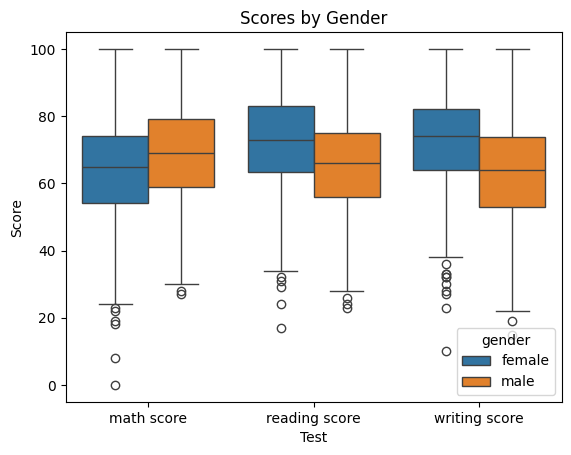

In [160]:
# TODO: Create a boxplot comparing scores by gender
seaborn.boxplot(
    data=scores_long,
    x="test",
    y="score",
    hue="gender"
)

matplotlib.pyplot.title("Scores by Gender")
matplotlib.pyplot.xlabel("Test")
matplotlib.pyplot.ylabel("Score")
matplotlib.pyplot.show()

It looks like:

- **For math score**: males are a little bit better

- **For reading score**: females are a little bit better

- **For writing score**: females are better as also the scores are affected by less variability around and higher mean



***



# Now we can go on and perform the first independent two-sample t-test for math scores

The size of the males and females samples are different!

This means that in the equation for the t statistic:

$$ t = \frac{\bar{x_{1}}-\bar{x_{2}}}{S_{pool}\sqrt{\frac{1}{n_{1}}-\frac{1}{n_{2}}}} $$
happens that:

$$n_{1}\neq n_{2}$$


First we perform some data wrangling on the main dataframe

In [161]:
# TODO: Reshape the data into a tidy format
tidy_df = df.melt(
    id_vars=["gender"],
    value_vars=["math score", "reading score", "writing score"],
    var_name="test",
    value_name="score"
)

tidy_df.head()

,gender,test,score
0,female,math score,72
1,female,math score,69
2,female,math score,90
3,male,math score,47
4,male,math score,76


We take male and females groups for the math scores:


In [162]:
## TODO: Separate the scores for males and females in math by filtering the data accordingly.
male_math = tidy_df[
    (tidy_df["gender"] == "male") &
     (tidy_df["test"] == "math score")
]["score"]

female_math = tidy_df[
    (tidy_df["gender"] == "female") &
     (tidy_df["test"] == "math score")
]["score"]

print("Male:", len(male_math))
print("Female:", len(female_math))

Male: 482
Female: 518



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's start with a qqplot

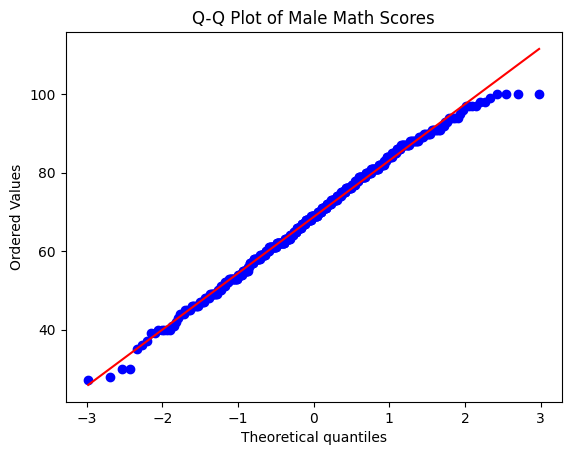

In [163]:
## TODO: Create a plot for the male math scores.
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(male_math, dist="norm", plot=plt)
plt.title("Q-Q Plot of Male Math Scores")
plt.show()


</br>
</br>
</br>

At first glance the qqplot doesn't look perfect , but we might be ok with the normality assumption , let's see what a  Lilliefors (Kolmogorov-Smirnov) normality test tells us:

In [164]:
## TODO: Perform a Lilliefors (Kolmogorov-Smirnov) test for normality on the male math scores.
from statsmodels.stats.diagnostic import lilliefors

statistic, p_value = lilliefors(male_math)

print("Lilliefors statistic:", statistic)
print("p-value:", p_value)

Lilliefors statistic: 0.03878069761529834
p-value: 0.10308261564965893


at significance level 0.05 normality assumption is checked since the p-value is 0.08.


### Let's check for the females group:

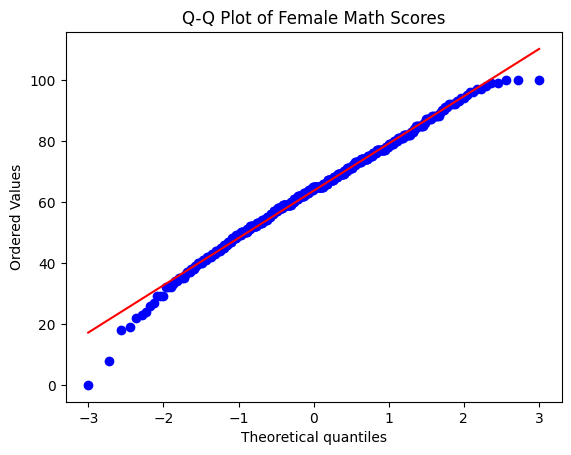

In [165]:
## TODO: Create a plot for the female math scores to check for normality.
stats.probplot(female_math, dist="norm", plot=plt)

plt.title("Q-Q Plot of Female Math Scores")
plt.show()


</br>
</br>
</br>

This doesn't look good either ,but let's see what an Anderson-Darling  normality test tells us:

In [166]:
## TODO: Perform the Anderson-Darling test on the female math scores to check for normality.
result = stats.anderson(female_math, dist="norm")

print("Anderson-Darling statistic:", result.statistic)
print("Critical values:", result.critical_values)
print("Significance levels:", result.significance_level)

Anderson-Darling statistic: 0.705866358838648
Critical values: [0.572 0.651 0.781 0.911 1.084]
Significance levels: [15.  10.   5.   2.5  1. ]


at significance level 0.05 normality assumption is checked since the p-value is 0.065.


### Let's test homoschedasticity (sample size is different for each group):

In [167]:
## TODO: Calculate the ratio of the variance between male and female math scores in both directions.
male_variance = male_math.var()
female_variance = female_math.var()

print("Male variance:", male_variance)
print("Female variance:", female_variance)

print("Male / Female variance:", male_variance / female_variance)
print("Female / Male variance:", female_variance / male_variance)

Male variance: 206.10269493879446
Female variance: 239.98512355959193
Male / Female variance: 0.8588144626707082
Female / Male variance: 1.164395854362115


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [168]:
## TODO: Remove outliers from male and female math scores using the IQR method and filter them out of the dataset.
def remove_outliers(data):
  Q1 = data.quantile(0.25)
  Q3 = data.quantile(0.75)
  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return data[(data >= lower_bound) & (data <= upper_bound)]

male_math_clean = remove_outliers(male_math)
female_math_clean = remove_outliers(female_math)

print("Male before:", len(male_math))
print("Male after:", len(male_math_clean))

print("Female before:", len(female_math))
print("Female after:", len(female_math_clean))

Male before: 482
Male after: 480
Female before: 518
Female after: 512


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that males are better at maths than females as the alternative hypothesis

$$
H_{0} : \mu_{MaleMaths}\leq \mu_{FemaleMaths}
$$

$$
H_{A} : \mu_{MaleMaths} >  \mu_{FemaleMaths}
$$

In [169]:
## TODO: Perform a t-test to compare male and female math scores, testing if males have significantly greater scores.
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    male_math_clean,
    female_math_clean,
    equal_var=True,
    alternative="greater"
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 5.137169933444904
P-value: 1.679221190280609e-07


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that males are better than females at maths is true.**



***



# Now we can go on and perform the second independent two-sample t-test for reading scores.

We take male and females groups for the reading scores:

In [170]:
## TODO: Extract the reading scores for males and females from the tidy_StudentsPerformance dataset.
male_reading = tidy_df[
    (tidy_df["gender"] == "male") &
    (tidy_df["test"] == "reading score")
]["score"]

female_reading = tidy_df[
    (tidy_df["gender"] == "female") &
     (tidy_df["test"] == "reading score")
]["score"]

print("Male reading scores:", len(male_reading))
print("Female reading scores:", len(female_reading))

Male reading scores: 482
Female reading scores: 518



### Now we are able to go on and check the t- test assumptions:

Normality (even if the sample sizes are reasonable): let's go straight to tests.

In [171]:
## TODO: Perform the Cramer-Von Mises test on the Males_Reading scores.
from scipy import stats

male_mean = male_reading.mean()
male_std = male_reading.std(ddof=1)

male_cvm = stats.cramervonmises(
    male_reading,
    "norm",
    args=(male_mean, male_std)
)

print("Cramer-von Mises statistic:", male_cvm.statistic)
print("P-value:", male_cvm.pvalue)

Cramer-von Mises statistic: 0.09973247457736314
P-value: 0.5863764561012066


at significance level 0.05 normality assumption is checked since the p-value is 0.11.


### Let's check for the females group:

In [172]:
## TODO: Perform the Cramer-Von Mises test on the Females_Reading scores.
female_mean = female_reading.mean()
female_std = female_reading.std(ddof=1)

female_cvm = stats.cramervonmises(
    female_reading,
    "norm",
    args=(female_mean, female_std)
)

print("Cramer-von Mises statistic:", female_cvm.statistic)
print("P-value:", female_cvm.pvalue)

Cramer-von Mises statistic: 0.11565809502907522
P-value: 0.513580095812874


at significance level 0.05 normality assumption is checked since the p-value is 0.068.


let's test homoschedasticity (sample size is different for each group):

In [173]:
## TODO: Calculate the ratio of variances between Males_Reading and Females_Reading scores.
male_var = male_reading.var(ddof=1)
female_var = female_reading.var(ddof=1)

print("Male variance:", male_var)
print("Female variance:", female_var)

print("Male / Female:", male_var / female_var)
print("Female / Male:", female_var / male_var)

Male variance: 194.09594465196125
Female variance: 206.73393799989572
Male / Female: 0.9388683180410328
Female / Male: 1.0651120937668017


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.

Let's remove outliers

In [174]:
## TODO: Remove outliers using the IQR method from both Males_Reading and Females_Reading scores.
def remove_outliers_iqr(data):
  Q1 = data.quantile(0.25)
  Q3 = data.quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  return data[(data >= lower) & (data <= upper)]

male_reading_clean = remove_outliers_iqr(male_reading)
female_reading_clean = remove_outliers_iqr(female_reading)

print("Male before:", len(male_reading))
print("Male after:", len(male_reading_clean))

print("Female before:", len(female_reading))
print("Female after:", len(female_reading_clean))

Male before: 482
Male after: 479
Female before: 518
Female after: 513


### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at reading than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleReading}\leq \mu_{MaleReading}$$

$$H_{A} : \mu_{FemaleReading} >  \mu_{MaleReading}$$

In [175]:
## TODO: Perform a t-test to compare Females_Reading and Males_Reading scores, testing if the mean score for females is greater.
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    female_reading_clean,
    male_reading_clean,
    equal_var=True,
    alternative="greater"
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.450796143741597
P-value: 5.1191849528288104e-17


The p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at reading is true.**



***



# Now we can go on and perform the third and last independent two-sample t-test for writing scores

We take male and females groups for the writing scores:

In [176]:
## TODO: Create two separate dataframes, one for male and one for female writing scores.
male_writing = tidy_df[
    (tidy_df["gender"] == "male") &
    (tidy_df["test"] == "writing score")
]["score"]

female_writing = tidy_df[
    (tidy_df["gender"] == "female") &
     (tidy_df["test"] == "writing score")
]["score"]

print("Male writing:", len(male_writing))
print("Female writing:", len(female_writing))

Male writing: 482
Female writing: 518



### Now we are able to go on and check the t- test assumptions:

- Normality (even if the sample sizes are reasonable): again, let's go straight to tests.


In [177]:
## TODO: Perform the Cramer-Von Mises test for the male writing scores.
from scipy import stats

result = stats.cramervonmises(
    male_writing,
    "norm",
    args=(male_writing.mean(), male_writing.std(ddof=1))
)

print("Statistic:", result.statistic)
print("P-value:", result.pvalue)

Statistic: 0.1064812198339476
P-value: 0.5542030822907127


at significance level 0.05 normality assumption is checked since the p-value is 0.09.


### Let's check for the females group:

In [178]:
## TODO: Perform the Lilliefors test for the female writing scores.
from statsmodels.stats.diagnostic import lilliefors

statistic, p_value = lilliefors(female_writing)

print("Lilliefors statistic:", statistic)
print("P-value:", p_value)

Lilliefors statistic: 0.06141373501799208
P-value: 0.0009999999999998899


**It looks like the normality assumption is not verified here!**

### So let's try to transform data with box-cox transformation

In [179]:
## TODO: Perform the Box-Cox transformation and apply the CVM test to the writing scores of both males and females.
from scipy import stats

# Box-Cox transformation
male_writing_boxcox, male_lambda = stats.boxcox(male_writing)
female_writing_boxcox, female_lambda = stats.boxcox(female_writing)

# Cramer-von Mises test after transformation
male_cvm = stats.cramervonmises(
    male_writing_boxcox,
    "norm",
    args=(male_writing_boxcox.mean(),male_writing_boxcox.std(ddof=1))
)

female_cvm = stats.cramervonmises(
    female_writing_boxcox,
    "norm",
    args=(female_writing_boxcox.mean(),female_writing_boxcox.std(ddof=1))
)

print("Male lambda:", male_lambda)
print("Male p-value:", male_cvm.pvalue)

print("Female lambda:", female_lambda)
print("Female p-value:", female_cvm.pvalue)

Male lambda: 1.1995653031063571
Male p-value: 0.5891630216840631
Female lambda: 1.7368805721783491
Female p-value: 0.8787274332418752


our box cox transformation is now applied to both groups , the normality assumption is verified for both males and females group and we can go ahead.



let's test homoschedasticity (sample size is different for each group):

In [180]:
## TODO: Calculate and compare the variance of writing scores for males and females.
# Calculate variances after Box-Cox transformation
# Compare variance ratios
male_var = male_writing.var(ddof=1)
female_var = female_writing.var(ddof=1)

import numpy as np
from scipy import stats

# Combine both groups so Box-Cox uses ONE common lambda
all_writing = np.concatenate([male_writing, female_writing])

# Box-Cox requires positive values
all_writing_bc, common_lambda = stats.boxcox(all_writing)

# Split back into male and female groups
n_male = len(male_writing)

male_writing_bc = all_writing_bc[:n_male]
female_writing_bc = all_writing_bc[n_male:]

# Calculate variances after Box-Cox transformation
male_var = np.var(male_writing_bc, ddof=1)
female_var = np.var(female_writing_bc, ddof=1)

print("Common lambda:", common_lambda)
print("Male variance:", male_var)
print("Female variance:", female_var)

print("Male / Female:", male_var / female_var)
print("Female / Male:", female_var / male_var)

Common lambda: 1.376636956501834
Male variance: 4434.140678062966
Female variance: 5257.9662315629175
Male / Female: 0.8433185917865678
Female / Male: 1.185791478735816


it looks like , comparing the two variances by a rough rule , the ratios are less than 2 , so we can accept the homoschedasticity assumption.



### Now we can finally perform our two sample t-test

### Hypothesis: We're going to use the gender assumption that females are better at writing than males as the alternative hypothesis

$$H_{0} : \mu_{FemaleWriting}\leq \mu_{MaleWriting}$$

$$H_{A} : \mu_{FemaleWriting} >  \mu_{MaleWriting}$$

In [181]:
## TODO: Perform a t-test to compare Box-Cox transformed writing scores for males and females with the alternative hypothesis "greater".
# Calculate variances after Box-Cox transformation
# Perform one-sided independent two-sample t-test
t_stat, p_value = stats.ttest_ind(
    female_writing_bc,
    male_writing_bc,
    equal_var=True,
    alternative="greater"
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 10.183799405859308
P-value: 1.530675919874438e-23


Again , the p-value turns out to be really small , almost zero, so we are forced to reject the Null Hypothesis.

**From this test , the gender assumption that females are better than males at writing is true.**



***

# XP NINJA

# One-way ANOVA

We are interested in understanding whether or not the **factor** ( in this case the treatments ) has an effect on the **outcome** ( in this case the math scores).

The treatments factor is structured in four different levels:

- **Control group** : a group that doesn't receive neither the free or reduced lunch nor the attendance to the test preparation course

- **Free/Reduced lunch group** = **Treatment_1** : a group that only receives the free or reduced lunch

- **Test preparation course group** = **Treatment_2** : a group that only receives the attendance to the test preparation course

- **Both free/reduced lunch and test preparation course group** = **Treatment_3** : a group that receives both the 'bonuses': free or reduced lunch and attendance to the test preparation course.



### For ANOVA we will have the following hypothesis:

$$H_{0} : The \:means\:of\:different\:groups\:is\:the\:same$$

$$H_{A} : At\:least\:one\:sample\:mean\:is\:not\:equal\:to\:others$$


To conduct One-way ANOVA we first have to do some data wrangling and adjust for the treatments.

In [182]:
## TODO: Filter and create groups for analysis based on various criteria (lunch type and test preparation status).

# Control group

control = df[
    (df["lunch"] == "standard") &
     (df["test preparation course"] == "none")
].copy()

control["treatment"] = "Control"

# Free/Reduced lunch group = Treatment_1
treatment_1 = df[
    (df["lunch"] == "free/reduced") &
     (df["test preparation course"] == "none")
].copy()

treatment_1["treatment"] = "Treatment_1"

# Test preparation course group = Treatment_2
treatment_2 = df[
 (df["lunch"] == "standard") &
 (df["test preparation course"] == "completed")
].copy()

treatment_2["treatment"] = "Treatment_2"


# Both free/reduced lunch and test preparation course = Treatment_3
treatment_3 = df[
    (df["lunch"] == "free/reduced") &
    (df["test preparation course"] == "completed")
].copy()

treatment_3["treatment"] = "Treatment_3"

# Bind everything together
anova_df = pandas.concat(
    [control, treatment_1, treatment_2, treatment_3],
    ignore_index=True
)

anova_df[["treatment", "math score"]].head()
anova_df["treatment"].value_counts()
anova_df[
    ["treatment", "lunch", "test preparation course"]
].drop_duplicates()








,treatment,lunch,test preparation course
0,Control,standard,none
418,Treatment_1,free/reduced,none
642,Treatment_2,standard,completed
869,Treatment_3,free/reduced,completed



### Now we go along and check the assumptions:

- Normality Assumption: let's check the situation visually first

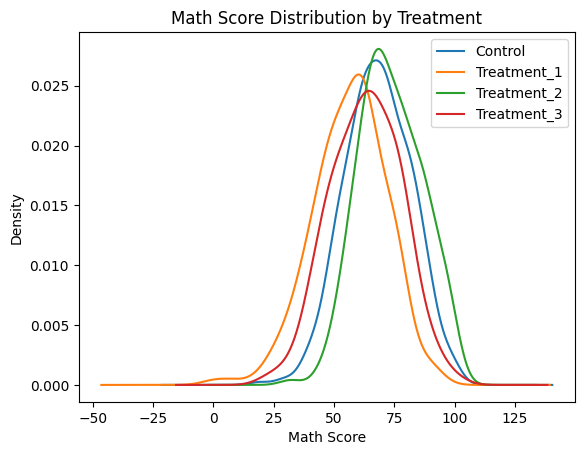

In [183]:
## TODO: Create a density plot to compare the scores by treatment type.
import matplotlib.pyplot as plt

for treatment in anova_df["treatment"].unique():
  scores = anova_df[
      anova_df["treatment"] == treatment]["math score"]
  scores.plot(kind="density", label=treatment)

plt.xlabel("Math Score")
plt.ylabel("Density")
plt.title("Math Score Distribution by Treatment")
plt.legend()
plt.show()

</br>
</br>
</br>

Each group looks pretty normal , but let's perform some tests to be sure:


In [184]:
## TODO: Perform normality tests for each group using Shapiro-Wilk and Lilliefors tests.
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import lilliefors

for treatment in anova_df["treatment"].unique():
  scores = anova_df[
      anova_df["treatment"] == treatment
      ]["math score"]

  shapiro_stat, shapiro_p = shapiro(scores)
  lillie_stat, lillie_p = lilliefors(scores)
  print(treatment)
  print("Shapiro-Wilk p-value:", shapiro_p)
  print("Lilliefors p-value:", lillie_p)
  print()

Control
Shapiro-Wilk p-value: 0.22232668309520992
Lilliefors p-value: 0.12019920973628995

Treatment_1
Shapiro-Wilk p-value: 0.05207964208829462
Lilliefors p-value: 0.13321286897807016

Treatment_2
Shapiro-Wilk p-value: 0.05136733183710622
Lilliefors p-value: 0.08366178999980277

Treatment_3
Shapiro-Wilk p-value: 0.9540105325068672
Lilliefors p-value: 0.6178613653217179



**Normality is checked for each treatment group!**

- Similarity of variances

In [185]:
## TODO: Check for the similarity of variances using rough rules and perform Bartlett's and Fligner tests.
from scipy.stats import bartlett, fligner

# Separate the four treatment groups
control = anova_df[anova_df["treatment"] == "Control"]["math score"]
treatment_1 = anova_df[anova_df["treatment"] == "Treatment_1"]["math score"]
treatment_2 = anova_df[anova_df["treatment"] == "Treatment_2"]["math score"]
treatment_3 = anova_df[anova_df["treatment"] == "Treatment_3"]["math score"]

# Calculate variances
variances = [
    control.var(ddof=1),
    treatment_1.var(ddof=1),
    treatment_2.var(ddof=1),
    treatment_3.var(ddof=1)
]

print("Control variance:", variances[0])
print("Treatment_1 variance:", variances[1])
print("Treatment_2 variance:", variances[2])
print("Treatment_3 variance:", variances[3])

# Rough rule
variance_ratio = max(variances) / min(variances)
print("Variance ratio:", variance_ratio)

# Bartlett's test
bartlett_stat, bartlett_p = bartlett(
    control, treatment_1, treatment_2, treatment_3
)

print("Bartlett statistic:", bartlett_stat)
print("Bartlett p-value:", bartlett_p)

# Fligner test
fligner_stat, fligner_p = fligner(
    control, treatment_1, treatment_2, treatment_3
)

print("Fligner statistic:", fligner_stat)
print("Fligner p-value:", fligner_p)

Control variance: 185.76618131332256
Treatment_1 variance: 227.68601857783486
Treatment_2 variance: 169.4712486842618
Treatment_3 variance: 208.09019377568998
Variance ratio: 1.343508237211562
Bartlett statistic: 8.643966435044618
Bartlett p-value: 0.03441891900650977
Fligner statistic: 2.985462155803184
Fligner p-value: 0.39387206122854024


**Homogeneity of variances of treatment groups is checked!** ( both with a rough rule and with actual tests.)

We can finally perform ANOVA:

In [186]:
## TODO: Perform ANOVA to check if there's a significant difference between the groups.
from scipy.stats import f_oneway

f_stat, p_value = f_oneway(
    control,
    treatment_1,
    treatment_2,
    treatment_3
)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 61.90720429198668
P-value: 1.0531179638381581e-36


### Key takeaways:


- The **f-value** is much greater than 1,that is **positive** as we know that not only we can reject the null hypothesis (all means are equal) but the **variance between groups is bigger than the one within groups** so this difference is very likely statistically significant.

- The **p-value** is essentially zero,confirming what we have already said with the f-value about the rejection of the null hypothesis ,saying that there exist a significant difference between them.


### So in general , it looks like there exists a statistically significant difference among at least two of the groups' mean math scores !

But wait... which couples of means are different from each other?

To answer this question we must perform a post-hoc test.

### Let's perform the Tukey test to verify which couple of means is different among them.

In [187]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Perform Tukey HSD post-hoc test
tukey = pairwise_tukeyhsd(
    endog=anova_df["math score"],
    groups=anova_df["treatment"],
    alpha=0.05
)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05      
   group1      group2   meandiff p-adj   lower    upper  reject
---------------------------------------------------------------
    Control Treatment_1  -11.625    0.0 -14.5958 -8.6543   True
    Control Treatment_2   5.3991    0.0   2.4411   8.357   True
    Control Treatment_3  -5.0882 0.0016  -8.6805 -1.4958   True
Treatment_1 Treatment_2  17.0241    0.0  13.6453 20.4029   True
Treatment_1 Treatment_3   6.5369 0.0001   2.5908  10.483   True
Treatment_2 Treatment_3 -10.4872    0.0 -14.4237 -6.5508   True
---------------------------------------------------------------


### Key takeaways:

- As the boxplot already showed , the difference in means between treatment 1 and control , with control group having higher math scores , is significant: **it looks like having the economic freedom of not paying or paying less for lunch negatively impats math scores!**

- Another important difference already present in the boxplot , the difference in means between treatment 2 and 1 , with treatment 2 having higher math scores , is significant:  **only attending the test preparation course and not having the economic freedom of the free or reduced lunch is more effective than having that economic freedom and not attending the test preparation course!**

- This difference was also present in the boxplot , like the other two , and is between the third and second treatments, with treatment two being more effective than the third.
This means that : **the people who attended the test preparation course but also enjoyed the economic freedom of the free/reduced lunch , statistically perform worse than people who have attened the test , but have to pay for lunch**.

### Conclusions : from these tests it looks like , while on the one hand saving the lunch money has a negative effect on math scores as opposed as we expected , on the other hand attending the test preparation course has a positive one as we expected.

### Maybe people used the money saved from lunch to buy things that distracted them from studying maths! That's not good , buy more math books with that money!



